In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("C:\AI-Based Indian Grocery Segmentation using Clustering\data\GroceryDataset.csv")
df.head(2)

,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description
0,Bakery & Desserts,$56.99,No Discount,Rated 4.3 out of 5 stars based on 265 reviews.,"David’s Cookies Mile High Peanut Butter Cake, ...",$,"""10"""" Peanut Butter Cake\nCertified Kosher OU-...",A cake the dessert epicure will die for!Our To...
1,Bakery & Desserts,$159.99,No Discount,Rated 5 out of 5 stars based on 1 reviews.,"The Cake Bake Shop 8"" Round Carrot Cake (16-22...",$,Spiced Carrot Cake with Cream Cheese Frosting ...,"Due to the perishable nature of this item, ord..."


In [3]:
df.shape

(1757, 8)

In [4]:
df.info()
df.describe(include="all").T
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Sub Category         1757 non-null   object
 1   Price                1754 non-null   object
 2   Discount             1757 non-null   object
 3   Rating               682 non-null    object
 4   Title                1757 non-null   object
 5   Currency             1752 non-null   object
 6   Feature              1739 non-null   object
 7   Product Description  1715 non-null   object
dtypes: object(8)
memory usage: 109.9+ KB


Index(['Sub Category', 'Price', 'Discount', 'Rating', 'Title', 'Currency',
       'Feature', 'Product Description'],
      dtype='object')

In [5]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_%": (df.isnull().sum() / len(df) * 100).round(2)
})

missing = missing[missing["Missing_Count"] > 0]

missing

,Missing_Count,Missing_%
Price,3,0.17
Rating,1075,61.18
Currency,5,0.28
Feature,18,1.02
Product Description,42,2.39


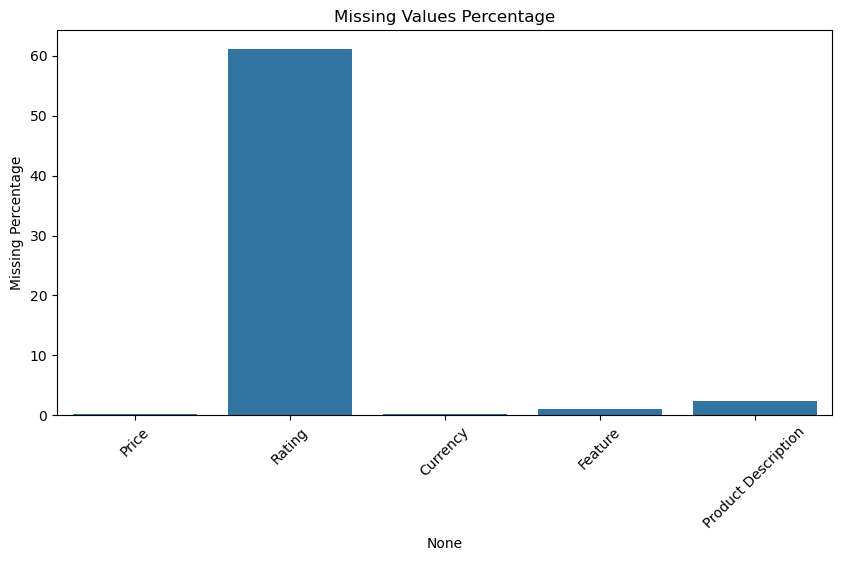

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Missing_%"]
)

plt.xticks(rotation=45)
plt.ylabel("Missing Percentage")
plt.title("Missing Values Percentage")
plt.show()

In [8]:
df.shape

(1757, 8)

In [9]:
missing


,Missing_Count,Missing_%
Price,3,0.17
Rating,1075,61.18
Currency,5,0.28
Feature,18,1.02
Product Description,42,2.39


In [10]:
print("Duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Duplicate rows: 3


,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description
1344,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...
1345,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...
1346,Paper & Plastic Products,$16.19,After $3.80 OFF,NaN,"Ziploc Seal Top Freezer Bag, Gallon, 38-count,...",$,Seal Top Bags 1-Gallon Freezer Bags 38 Bag...,4 - 38 Count Boxes\n152 Gallon Freezer Bags To...


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Sub Category: 19 unique values
Price: 184 unique values
Discount: 42 unique values
Rating: 483 unique values
Title: 1484 unique values
Currency: 1 unique values
Feature: 1401 unique values
Product Description: 1435 unique values


In [13]:
print(df["Sub Category"].value_counts())

Sub Category
Snacks                          293
Pantry & Dry Goods              171
Candy                           154
Beverages & Water               148
Meat & Seafood                  144
Kirkland Signature Grocery      122
Coffee                           95
Cleaning Supplies                94
Gift Baskets                     89
Paper & Plastic Products         85
Household                        81
Floral                           75
Seafood                          47
Laundry Detergent & Supplies     39
Organic                          33
Bakery & Desserts                33
Deli                             21
Breakfast                        21
Poultry                           9
Name: count, dtype: int64


In [14]:
df.dtypes

Sub Category           object
Price                  object
Discount               object
Rating                 object
Title                  object
Currency               object
Feature                object
Product Description    object
dtype: object

Price Feature Extraction

In [15]:
df["Price_num"] = (
    df["Price"]
    .astype(str)
    .str.extract(r"([\d,.]+)")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [16]:
df[["Price", "Price_num"]].head()

,Price,Price_num
0,$56.99,56.99
1,$159.99,159.99
2,$44.99,44.99
3,$39.99,39.99
4,$59.99,59.99


In [17]:
df["Price_num"].describe()

count    1751.000000
mean       60.871302
std       120.746672
min         3.990000
25%        14.990000
50%        23.990000
75%        52.890000
max      1999.990000
Name: Price_num, dtype: float64

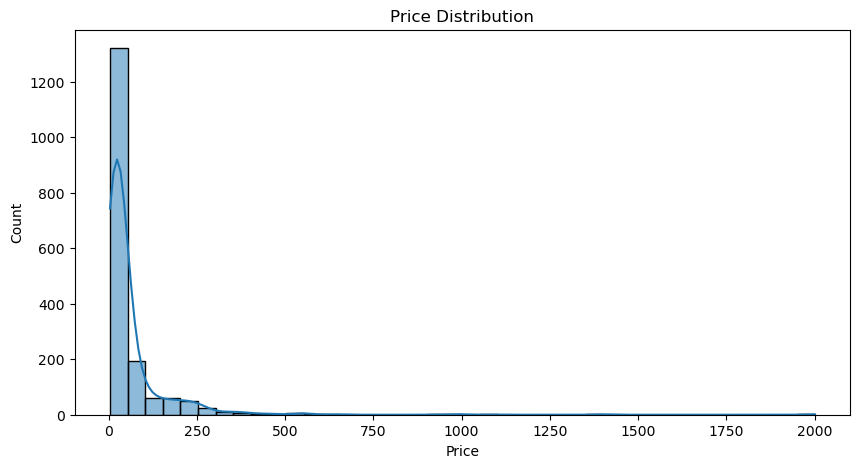

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df["Price_num"], bins=40, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

Discount Feature Extraction

In [19]:
df["Discount_num"] = (
    df["Discount"]
    .astype(str)
    .str.extract(r"After \$([\d,.]+) OFF")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
    .fillna(0)
)

In [20]:
df[["Discount", "Discount_num"]].head(20)

,Discount,Discount_num
0,No Discount,0.0
1,No Discount,0.0
2,No Discount,0.0
3,No Discount,0.0
4,No Discount,0.0
5,No Discount,0.0
6,No Discount,0.0
7,No Discount,0.0
8,No Discount,0.0
9,No Discount,0.0


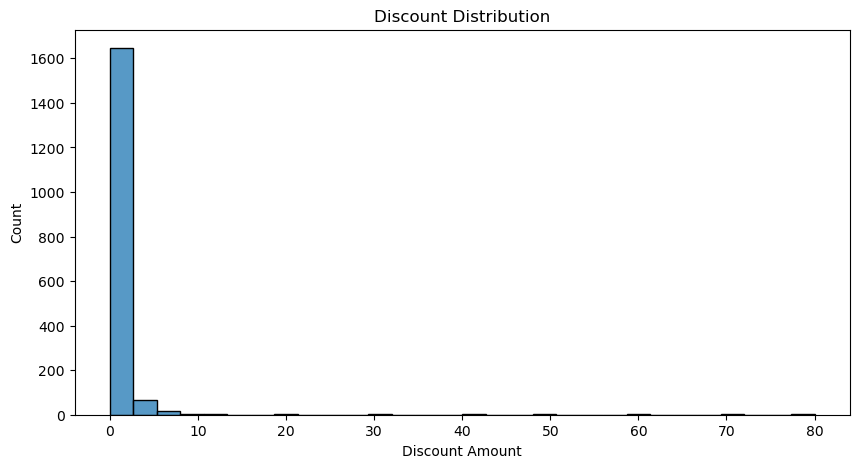

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Discount_num"], bins=30)

plt.title("Discount Distribution")
plt.xlabel("Discount Amount")
plt.show()

In [22]:
df["Discount_num"].gt(0).value_counts()

Discount_num
False    1634
True      120
Name: count, dtype: int64

Rating + Reviews Extraction

In [24]:
df["Rating_num"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"Rated\s+([0-9.]+)")[0]
    .astype(float)
)

In [25]:
df["Reviews_num"] = (
    df["Rating"]
    .astype(str)
    .str.extract(r"based on\s+([\d,]+)\s+reviews")[0]
    .str.replace(",", "", regex=False)
    .astype(float)
)


In [26]:
df[
    ["Rating", "Rating_num", "Reviews_num"]
].head(10)

,Rating,Rating_num,Reviews_num
0,Rated 4.3 out of 5 stars based on 265 reviews.,4.3,265.0
1,Rated 5 out of 5 stars based on 1 reviews.,5.0,1.0
2,Rated 4.1 out of 5 stars based on 441 reviews.,4.1,441.0
3,Rated 4.7 out of 5 stars based on 9459 reviews.,4.7,9459.0
4,Rated 4.5 out of 5 stars based on 758 reviews.,4.5,758.0
5,Rated 4.4 out of 5 stars based on 369 reviews.,4.4,369.0
6,Rated 4.7 out of 5 stars based on 2241 reviews.,4.7,2241.0
7,Rated 4.4 out of 5 stars based on 232 reviews.,4.4,232.0
8,Rated 4.4 out of 5 stars based on 1679 reviews.,4.4,1679.0
9,Rated 5 out of 5 stars based on 2 reviews.,5.0,2.0


Rating Distribution

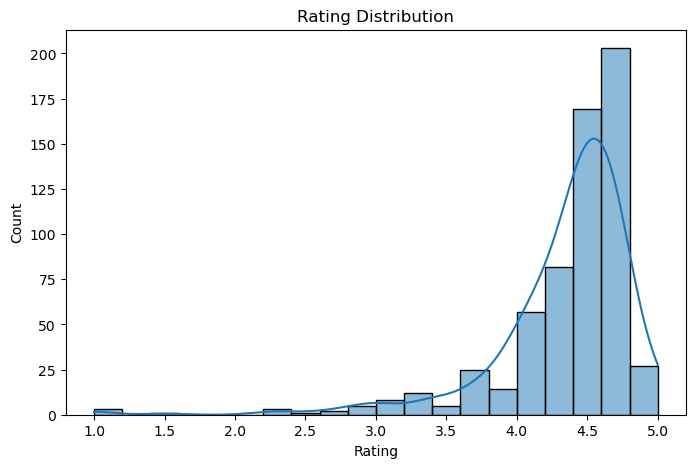

In [27]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Rating_num"].dropna(),
    bins=20,
    kde=True
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.show()

In [28]:
df["Rating_num"].describe()

count    617.000000
mean       4.340357
std        0.510037
min        1.000000
25%        4.200000
50%        4.500000
75%        4.600000
max        5.000000
Name: Rating_num, dtype: float64

Reviews Distribution

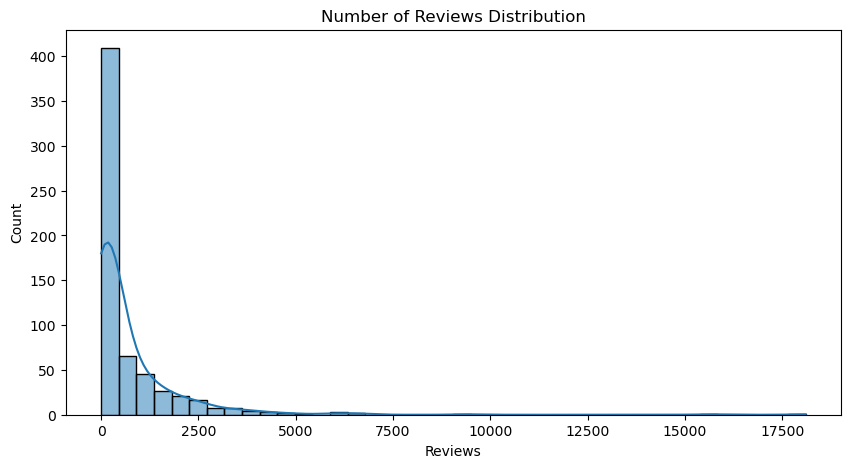

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Reviews_num"].dropna(),
    bins=40,
    kde=True
)

plt.title("Number of Reviews Distribution")
plt.xlabel("Reviews")
plt.show()

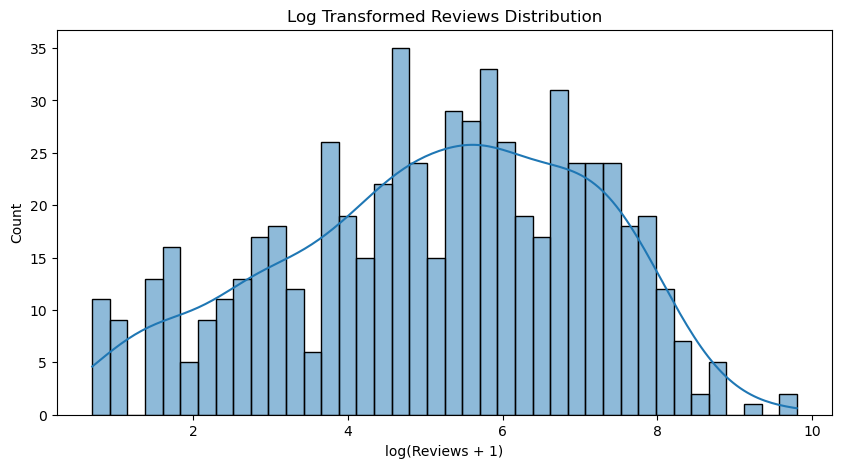

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["Reviews_num"].dropna()),
    bins=40,
    kde=True
)

plt.title("Log Transformed Reviews Distribution")
plt.xlabel("log(Reviews + 1)")
plt.show()

Category Analysis

In [31]:
category_counts = df["Sub Category"].value_counts()

category_counts

Sub Category
Snacks                          293
Pantry & Dry Goods              171
Candy                           154
Beverages & Water               148
Meat & Seafood                  144
Kirkland Signature Grocery      122
Coffee                           95
Cleaning Supplies                94
Gift Baskets                     89
Paper & Plastic Products         85
Household                        81
Floral                           75
Seafood                          47
Laundry Detergent & Supplies     39
Organic                          33
Bakery & Desserts                33
Deli                             21
Breakfast                        21
Poultry                           9
Name: count, dtype: int64

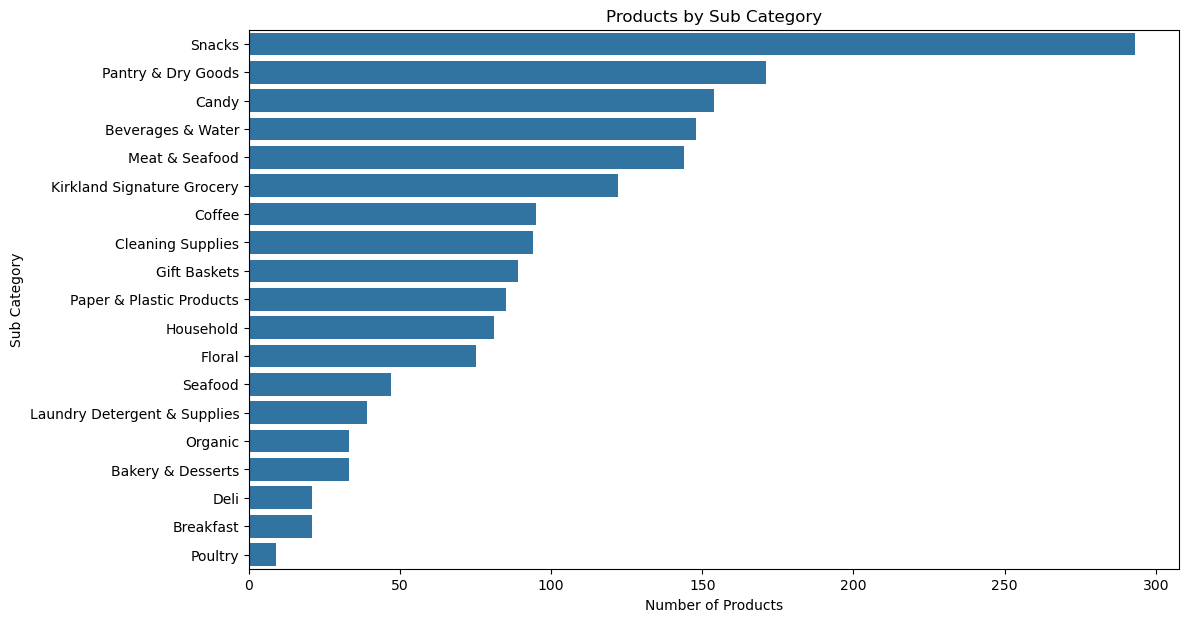

In [32]:
plt.figure(figsize=(12,7))

sns.countplot(
    data=df,
    y="Sub Category",
    order=df["Sub Category"].value_counts().index
)

plt.title("Products by Sub Category")
plt.xlabel("Number of Products")
plt.ylabel("Sub Category")
plt.show()

Category vs Price

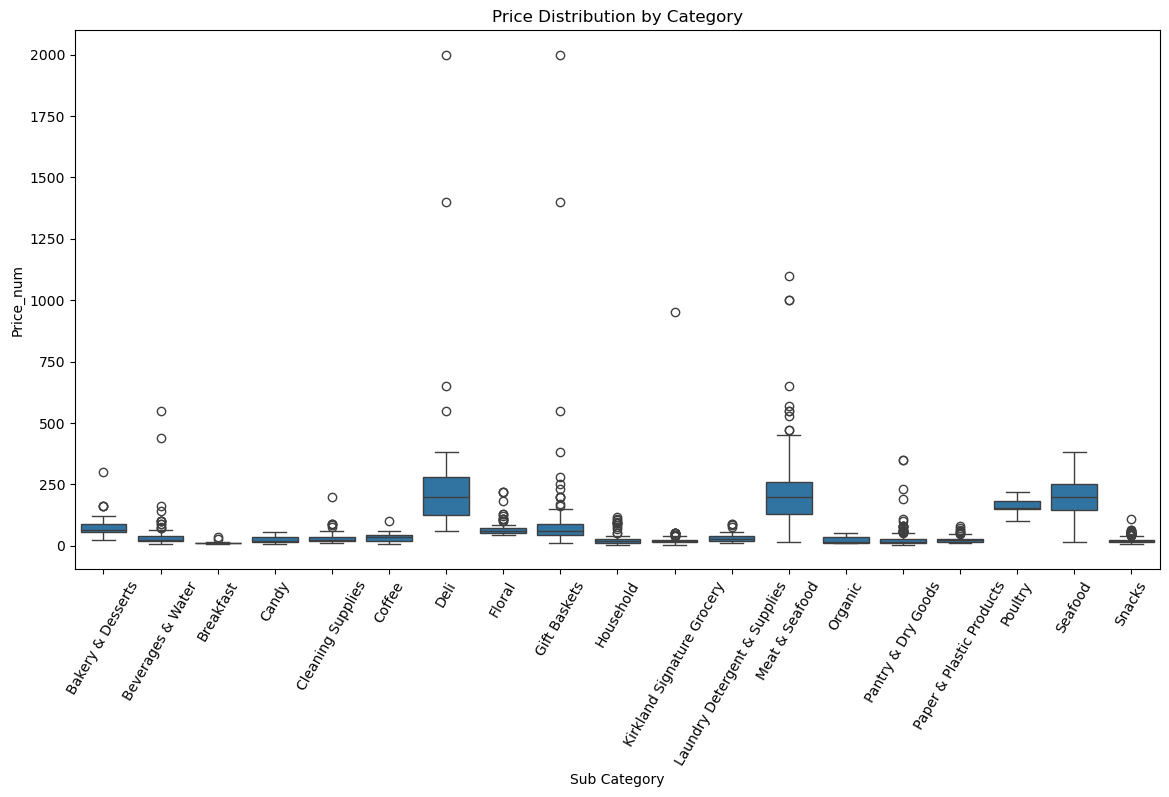

In [33]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=df,
    x="Sub Category",
    y="Price_num"
)

plt.xticks(rotation=60)
plt.title("Price Distribution by Category")
plt.show()

Category Average Price

In [34]:
category_price = (
    df.groupby("Sub Category")["Price_num"]
    .mean()
    .sort_values(ascending=False)
)

category_price

Sub Category
Deli                            370.704286
Meat & Seafood                  229.570280
Seafood                         195.521489
Poultry                         159.990000
Gift Baskets                    118.742809
Bakery & Desserts                83.414242
Floral                           71.976667
Beverages & Water                36.703514
Laundry Detergent & Supplies     33.895128
Coffee                           32.880526
Cleaning Supplies                30.357021
Pantry & Dry Goods               29.103450
Household                        28.335679
Kirkland Signature Grocery       28.119508
Paper & Plastic Products         25.667647
Candy                            25.069221
Organic                          22.420303
Snacks                           21.535890
Breakfast                        13.304286
Name: Price_num, dtype: float64

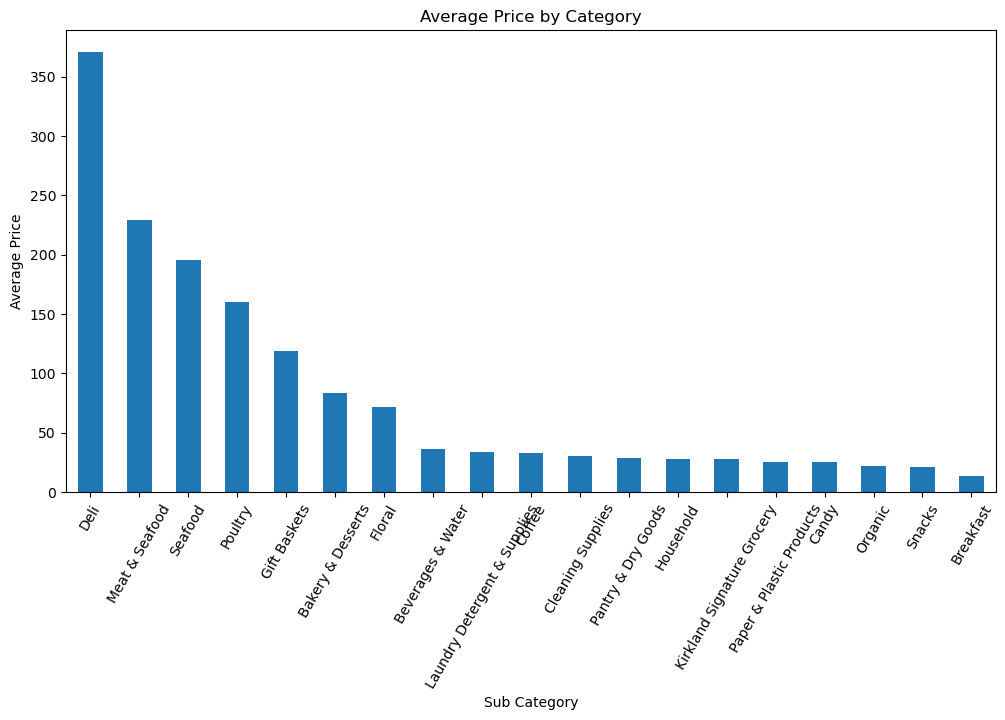

In [35]:
plt.figure(figsize=(12,6))

category_price.plot(kind="bar")

plt.title("Average Price by Category")
plt.ylabel("Average Price")
plt.xticks(rotation=60)
plt.show()

Discount Analysis

In [36]:
discount_category = (
    df.groupby("Sub Category")["Discount_num"]
    .mean()
    .sort_values(ascending=False)
)

discount_category

Sub Category
Deli                            6.190476
Seafood                         2.765957
Meat & Seafood                  2.638889
Gift Baskets                    1.685393
Laundry Detergent & Supplies    1.423077
Breakfast                       0.895238
Cleaning Supplies               0.839362
Coffee                          0.547368
Beverages & Water               0.537162
Pantry & Dry Goods              0.387719
Paper & Plastic Products        0.383529
Snacks                          0.293515
Candy                           0.248701
Kirkland Signature Grocery      0.217213
Poultry                         0.000000
Bakery & Desserts               0.000000
Organic                         0.000000
Floral                          0.000000
Household                       0.000000
Name: Discount_num, dtype: float64

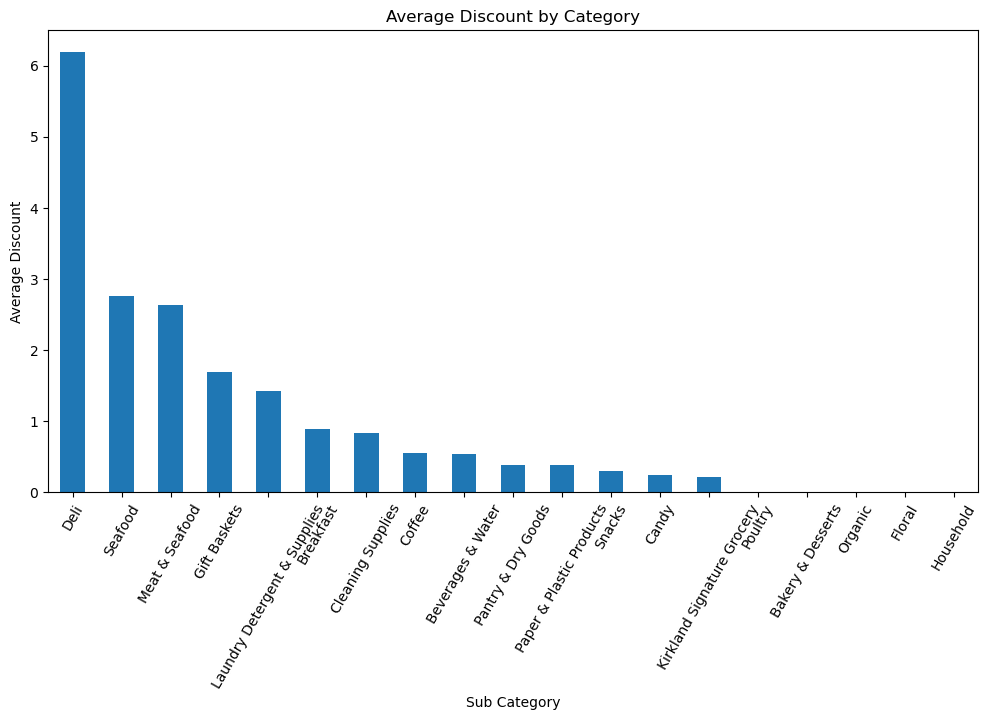

In [37]:
plt.figure(figsize=(12,6))

discount_category.plot(kind="bar")

plt.title("Average Discount by Category")
plt.ylabel("Average Discount")
plt.xticks(rotation=60)
plt.show()

Missing Rating by Category

In [38]:
rating_missing = (
    df.groupby("Sub Category")["Rating_num"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

rating_missing

Sub Category
Household                       100.000000
Breakfast                        90.476190
Candy                            87.662338
Snacks                           87.372014
Kirkland Signature Grocery       84.426230
Beverages & Water                83.783784
Paper & Plastic Products         83.529412
Organic                          75.757576
Pantry & Dry Goods               74.269006
Coffee                           61.052632
Cleaning Supplies                60.638298
Laundry Detergent & Supplies     58.974359
Floral                           25.333333
Gift Baskets                     15.730337
Seafood                          12.765957
Bakery & Desserts                12.121212
Meat & Seafood                    9.722222
Deli                              4.761905
Poultry                           0.000000
Name: Rating_num, dtype: float64

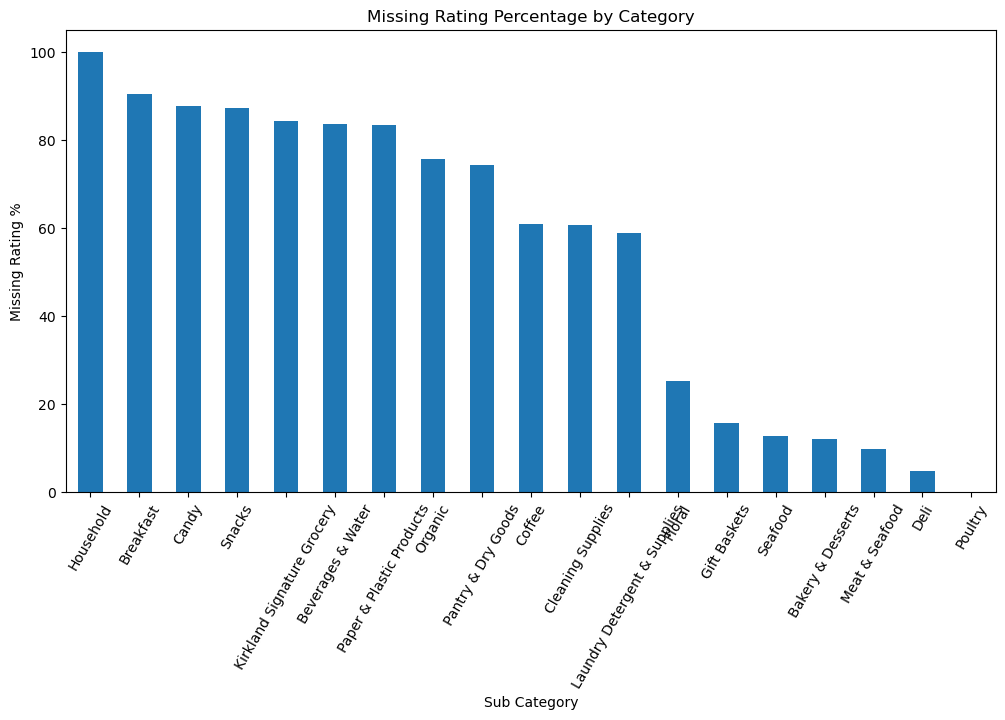

In [39]:
plt.figure(figsize=(12,6))

rating_missing.plot(kind="bar")

plt.ylabel("Missing Rating %")
plt.title("Missing Rating Percentage by Category")
plt.xticks(rotation=60)
plt.show()

Outlier Analysis

In [41]:
numeric_cols = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num"
]

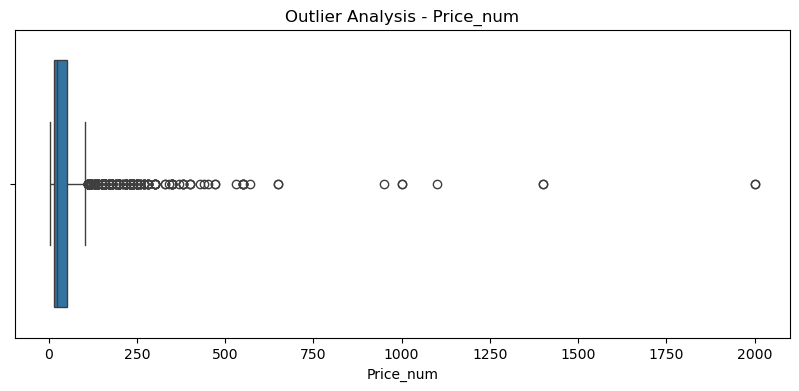

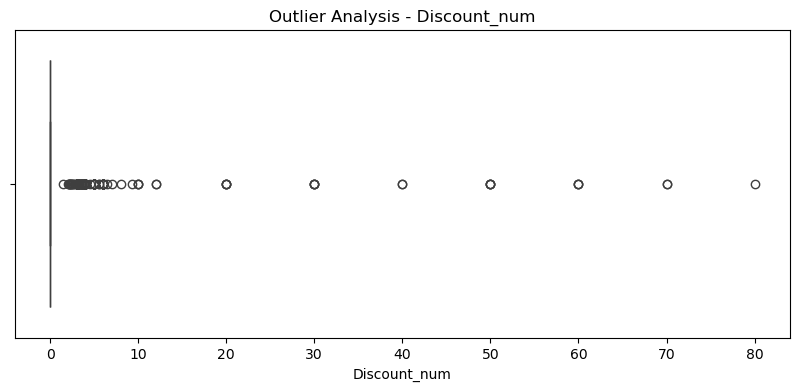

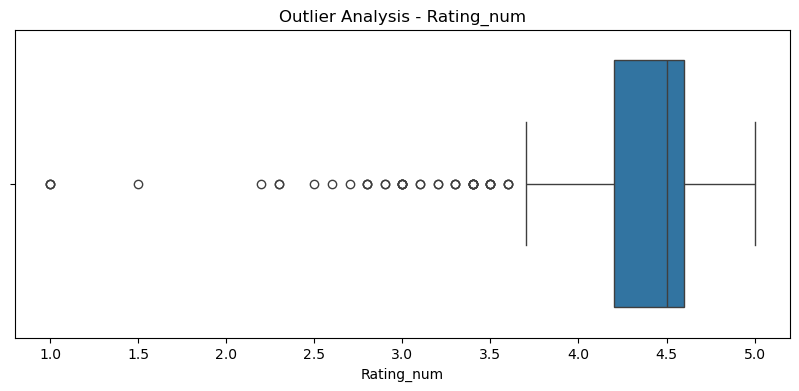

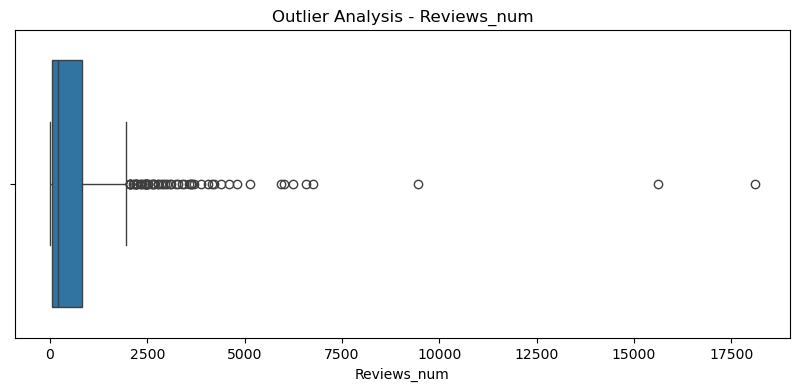

In [42]:
for col in numeric_cols:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Outlier Analysis - {col}")
    plt.show()

In [43]:
def outlier_count(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return ((data[column] < lower) | (data[column] > upper)).sum()

In [44]:
for col in numeric_cols:
    print(col, ":", outlier_count(df, col))

Price_num : 237
Discount_num : 120
Rating_num : 43
Reviews_num : 61


Correlation Analysis

In [45]:
corr_cols = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num"
]

corr = df[corr_cols].corr()

corr

,Price_num,Discount_num,Rating_num,Reviews_num
Price_num,1.000000,0.070127,-0.003628,-0.143516
Discount_num,0.070127,1.000000,0.058981,0.006927
Rating_num,-0.003628,0.058981,1.000000,0.111706
Reviews_num,-0.143516,0.006927,0.111706,1.000000


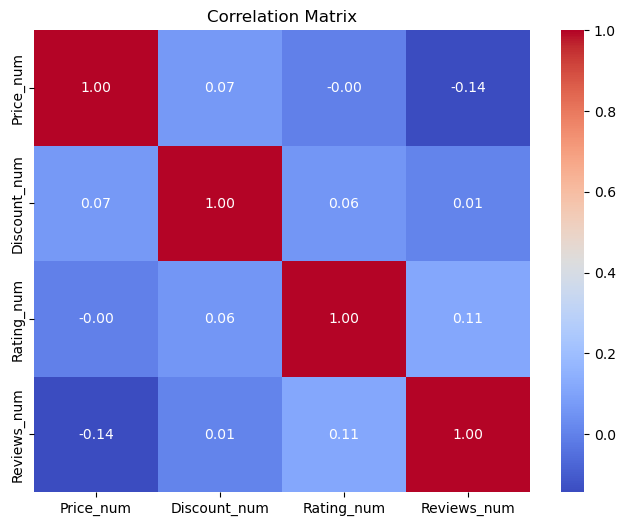

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

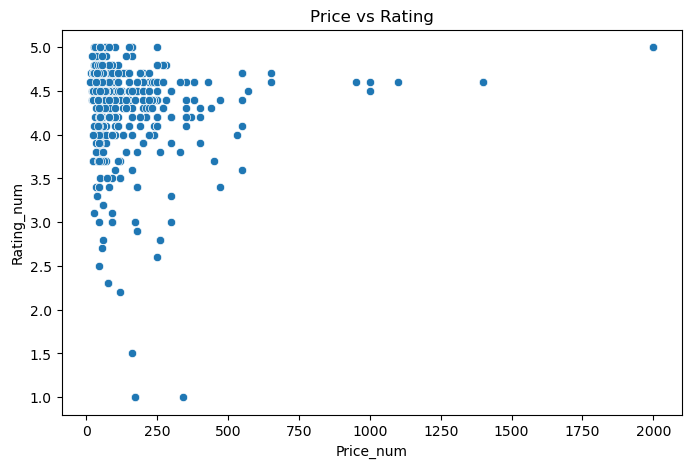

In [47]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Price_num",
    y="Rating_num"
)

plt.title("Price vs Rating")
plt.show()

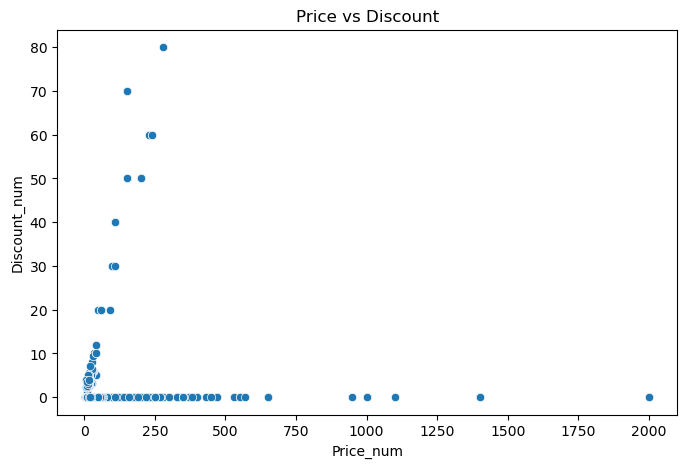

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Price_num",
    y="Discount_num"
)

plt.title("Price vs Discount")
plt.show()

In [49]:
df["Title_Length"] = df["Title"].fillna("").str.len()

In [50]:
df["Feature_Length"] = df["Feature"].fillna("").str.len()

In [51]:
df["Description_Length"] = (
    df["Product Description"]
    .fillna("")
    .str.len()
)

In [52]:
df[
    [
        "Title_Length",
        "Feature_Length",
        "Description_Length"
    ]
].describe()

,Title_Length,Feature_Length,Description_Length
count,1754.000000,1754.000000,1754.000000
mean,57.805587,104.741163,643.265108
std,18.249815,52.753917,752.381071
min,11.000000,0.000000,0.000000
25%,46.000000,72.000000,76.000000
50%,56.000000,93.000000,267.500000
75%,67.000000,126.000000,1080.750000
max,150.000000,416.000000,4743.000000


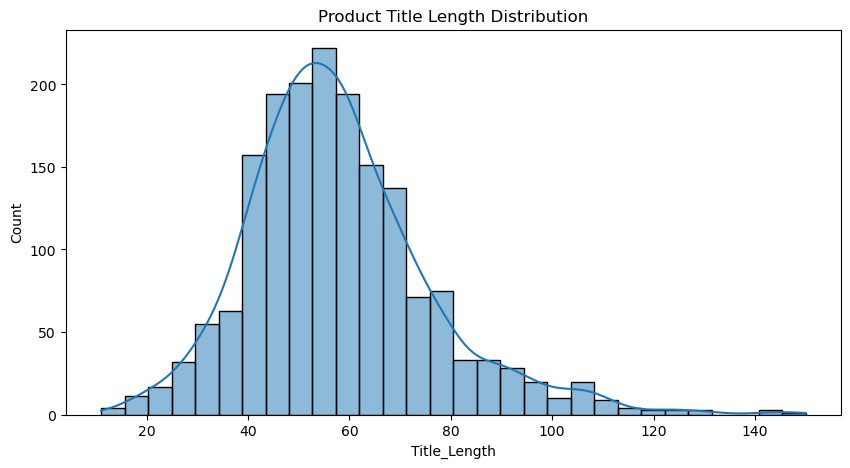

In [53]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Title_Length"],
    bins=30,
    kde=True
)

plt.title("Product Title Length Distribution")
plt.show()

In [54]:
numeric_features = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num",
    "Title_Length",
    "Feature_Length",
    "Description_Length"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Price_num,1751.0,60.871302,120.746672,3.99,14.99,23.99,52.89,1999.99
Discount_num,1754.0,0.755074,5.165837,0.00,0.00,0.00,0.00,80.00
Rating_num,617.0,4.340357,0.510037,1.00,4.20,4.50,4.60,5.00
Reviews_num,617.0,706.277147,1420.422106,1.00,41.00,208.00,827.00,18098.00
Title_Length,1754.0,57.805587,18.249815,11.00,46.00,56.00,67.00,150.00
Feature_Length,1754.0,104.741163,52.753917,0.00,72.00,93.00,126.00,416.00
Description_Length,1754.0,643.265108,752.381071,0.00,76.00,267.50,1080.75,4743.00


In [55]:
df.shape

(1754, 15)

In [56]:
df.head()

,Sub Category,Price,Discount,Rating,Title,Currency,Feature,Product Description,Price_num,Discount_num,Rating_num,Reviews_num,Title_Length,Feature_Length,Description_Length
0,Bakery & Desserts,$56.99,No Discount,Rated 4.3 out of 5 stars based on 265 reviews.,"David’s Cookies Mile High Peanut Butter Cake, ...",$,"""10"""" Peanut Butter Cake\nCertified Kosher OU-...",A cake the dessert epicure will die for!Our To...,56.99,0.0,4.3,265.0,67,58,764
1,Bakery & Desserts,$159.99,No Discount,Rated 5 out of 5 stars based on 1 reviews.,"The Cake Bake Shop 8"" Round Carrot Cake (16-22...",$,Spiced Carrot Cake with Cream Cheese Frosting ...,"Due to the perishable nature of this item, ord...",159.99,0.0,5.0,1.0,56,161,1343
2,Bakery & Desserts,$44.99,No Discount,Rated 4.1 out of 5 stars based on 441 reviews.,"St Michel Madeleine, Classic French Sponge Cak...",$,100 count\nIndividually wrapped\nMade in and I...,Moist and buttery sponge cakes with the tradit...,44.99,0.0,4.1,441.0,59,99,1173
3,Bakery & Desserts,$39.99,No Discount,Rated 4.7 out of 5 stars based on 9459 reviews.,"David's Cookies Butter Pecan Meltaways 32 oz, ...",$,Butter Pecan Meltaways\n32 oz 2-Pack\nNo Prese...,These delectable butter pecan meltaways are th...,39.99,0.0,4.7,9459.0,52,88,629
4,Bakery & Desserts,$59.99,No Discount,Rated 4.5 out of 5 stars based on 758 reviews.,"David’s Cookies Premier Chocolate Cake, 7.2 lb...",$,"""10"" Four Layer Chocolate Cake\nCertified Kosh...",A cake the dessert epicure will die for!To the...,59.99,0.0,4.5,758.0,59,62,814


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754 entries, 0 to 1753
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sub Category         1754 non-null   object 
 1   Price                1751 non-null   object 
 2   Discount             1754 non-null   object 
 3   Rating               682 non-null    object 
 4   Title                1754 non-null   object 
 5   Currency             1749 non-null   object 
 6   Feature              1736 non-null   object 
 7   Product Description  1712 non-null   object 
 8   Price_num            1751 non-null   float64
 9   Discount_num         1754 non-null   float64
 10  Rating_num           617 non-null    float64
 11  Reviews_num          617 non-null    float64
 12  Title_Length         1754 non-null   int64  
 13  Feature_Length       1754 non-null   int64  
 14  Description_Length   1754 non-null   int64  
dtypes: float64(4), int64(3), object(8)
mem

In [58]:
df.isnull().sum()

Sub Category              0
Price                     3
Discount                  0
Rating                 1072
Title                     0
Currency                  5
Feature                  18
Product Description      42
Price_num                 3
Discount_num              0
Rating_num             1137
Reviews_num            1137
Title_Length              0
Feature_Length            0
Description_Length        0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df[df["Rating"].notna() & df["Rating_num"].isna()][
    ["Rating", "Rating_num"]
].head(20)

,Rating,Rating_num
16,No Reviews,NaN
19,No Reviews,NaN
31,No Reviews,NaN
32,No Reviews,NaN
218,No Reviews,NaN
315,No Reviews,NaN
354,No Reviews,NaN
355,No Reviews,NaN
389,through,NaN
395,No Reviews,NaN


In [61]:
print(
    df["Rating"].notna().sum(),
    df["Rating_num"].notna().sum()
)

682 617


In [62]:

df["Rating"].dropna().head(30).tolist()

['Rated 4.3 out of 5 stars based on 265 reviews.',
 'Rated 5 out of 5 stars based on 1 reviews.',
 'Rated 4.1 out of 5 stars based on 441 reviews.',
 'Rated 4.7 out of 5 stars based on 9459 reviews.',
 'Rated 4.5 out of 5 stars based on 758 reviews.',
 'Rated 4.4 out of 5 stars based on 369 reviews.',
 'Rated 4.7 out of 5 stars based on 2241 reviews.',
 'Rated 4.4 out of 5 stars based on 232 reviews.',
 'Rated 4.4 out of 5 stars based on 1679 reviews.',
 'Rated 5 out of 5 stars based on 2 reviews.',
 'Rated 4 out of 5 stars based on 357 reviews.',
 'Rated 3 out of 5 stars based on 1 reviews.',
 'Rated 4.7 out of 5 stars based on 273 reviews.',
 'Rated 4.6 out of 5 stars based on 369 reviews.',
 'Rated 4.6 out of 5 stars based on 133 reviews.',
 'Rated 4.5 out of 5 stars based on 452 reviews.',
 'No Reviews',
 'Rated 4.2 out of 5 stars based on 85 reviews.',
 'Rated 1.5 out of 5 stars based on 2 reviews.',
 'No Reviews',
 'Rated 3.6 out of 5 stars based on 5 reviews.',
 'Rated 3 out of 

In [63]:
df["Rating"].dropna().sample(20, random_state=42).tolist()

['Rated 4.8 out of 5 stars based on 465 reviews.',
 'Rated 4.1 out of 5 stars based on 107 reviews.',
 'Rated 3.9 out of 5 stars based on 1210 reviews.',
 'Rated 4.9 out of 5 stars based on 7 reviews.',
 'Rated 4.8 out of 5 stars based on 477 reviews.',
 'No Reviews',
 'Rated 4.7 out of 5 stars based on 5134 reviews.',
 'Rated 4.4 out of 5 stars based on 1278 reviews.',
 'No Reviews',
 'Rated 4.7 out of 5 stars based on 837 reviews.',
 'Rated 4.6 out of 5 stars based on 63 reviews.',
 'Rated 4.8 out of 5 stars based on 84 reviews.',
 'Rated 4.4 out of 5 stars based on 4171 reviews.',
 'Rated 4.6 out of 5 stars based on 429 reviews.',
 'Rated 4.5 out of 5 stars based on 1307 reviews.',
 'Rated 4.1 out of 5 stars based on 1181 reviews.',
 'through',
 'Rated 4.8 out of 5 stars based on 1251 reviews.',
 'Rated 3 out of 5 stars based on 1 reviews.',
 'No Reviews']

In [64]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing[missing["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Price,3,0.17
Rating,1072,61.12
Currency,5,0.29
Feature,18,1.03
Product Description,42,2.39
Price_num,3,0.17
Rating_num,1137,64.82
Reviews_num,1137,64.82


In [65]:
print("=" * 50)
print("DATASET STATUS")
print("=" * 50)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nNumerical Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(include="object").columns.tolist())

DATASET STATUS

Shape:
(1754, 15)

Columns:
['Sub Category', 'Price', 'Discount', 'Rating', 'Title', 'Currency', 'Feature', 'Product Description', 'Price_num', 'Discount_num', 'Rating_num', 'Reviews_num', 'Title_Length', 'Feature_Length', 'Description_Length']

Data Types:
Sub Category            object
Price                   object
Discount                object
Rating                  object
Title                   object
Currency                object
Feature                 object
Product Description     object
Price_num              float64
Discount_num           float64
Rating_num             float64
Reviews_num            float64
Title_Length             int64
Feature_Length           int64
Description_Length       int64
dtype: object

Missing Values:
Sub Category              0
Price                     3
Discount                  0
Rating                 1072
Title                     0
Currency                  5
Feature                  18
Product Description      42
Price_

In [66]:
df[
    [
        "Price",
        "Price_num",
        "Discount",
        "Discount_num",
        "Rating",
        "Rating_num",
        "Reviews_num"
    ]
].head(10)


,Price,Price_num,Discount,Discount_num,Rating,Rating_num,Reviews_num
0,$56.99,56.99,No Discount,0.0,Rated 4.3 out of 5 stars based on 265 reviews.,4.3,265.0
1,$159.99,159.99,No Discount,0.0,Rated 5 out of 5 stars based on 1 reviews.,5.0,1.0
2,$44.99,44.99,No Discount,0.0,Rated 4.1 out of 5 stars based on 441 reviews.,4.1,441.0
3,$39.99,39.99,No Discount,0.0,Rated 4.7 out of 5 stars based on 9459 reviews.,4.7,9459.0
4,$59.99,59.99,No Discount,0.0,Rated 4.5 out of 5 stars based on 758 reviews.,4.5,758.0
5,$59.99,59.99,No Discount,0.0,Rated 4.4 out of 5 stars based on 369 reviews.,4.4,369.0
6,$74.99,74.99,No Discount,0.0,Rated 4.7 out of 5 stars based on 2241 reviews.,4.7,2241.0
7,$59.99,59.99,No Discount,0.0,Rated 4.4 out of 5 stars based on 232 reviews.,4.4,232.0
8,$29.99,29.99,No Discount,0.0,Rated 4.4 out of 5 stars based on 1679 reviews.,4.4,1679.0
9,$159.99,159.99,No Discount,0.0,Rated 5 out of 5 stars based on 2 reviews.,5.0,2.0


In [67]:
ml_features = [
    "Price_num",
    "Discount_num",
    "Rating_num",
    "Reviews_num",
    "Title_Length",
    "Feature_Length",
    "Description_Length"
]

In [68]:
for col in ml_features:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [69]:
df[ml_features].isnull().sum()

Price_num             0
Discount_num          0
Rating_num            0
Reviews_num           0
Title_Length          0
Feature_Length        0
Description_Length    0
dtype: int64

In [70]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Shape: (1754, 15)

Missing Values:
Sub Category              0
Price                     3
Discount                  0
Rating                 1072
Title                     0
Currency                  5
Feature                  18
Product Description      42
Price_num                 0
Discount_num              0
Rating_num                0
Reviews_num               0
Title_Length              0
Feature_Length            0
Description_Length        0
dtype: int64

Duplicate Rows:
0


In [71]:
output_path = "../data/GroceryDataset_EDA_Final.csv"

df.to_csv(
    output_path,
    index=False
)

print("Final dataset saved successfully!")
print(output_path)

Final dataset saved successfully!
../data/GroceryDataset_EDA_Final.csv
